In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
df_train = pd.read_csv("titanic/train.csv")
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])
df_train.drop("Cabin", axis=1, inplace=True)

In [6]:
df_train["Sex"] = df_train["Sex"].map({"male" : 0, "female" : 1})
df_train = pd.get_dummies(df_train, columns=["Embarked"], drop_first=True)

In [7]:
X_train = df_train.drop(["PassengerId", "Survived", "Name", "Ticket"], axis=1)
y_train = df_train["Survived"]

In [8]:
df_test = pd.read_csv("titanic/test.csv")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [10]:
avg_age = X_train["Age"].median()
df_test["Age"] = df_test["Age"].fillna(avg_age)

fare_median = X_train["Fare"].median()
df_test["Fare"] = df_test["Fare"].fillna(fare_median)

df_test.drop("Cabin", axis=1)
df_test["Sex"] = df_test["Sex"].map({"male" : 0, "female" : 1})
df_test = pd.get_dummies(df_test, columns=["Embarked"], drop_first=True)

In [11]:
X_test = df_test.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [12]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [13]:
df_train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
scaler = StandardScaler()
X_train[["Age", "Fare"]] = scaler.fit_transform(X_train[["Age", "Fare"]])
X_test[["Age", "Fare"]] = scaler.transform(X_test[["Age", "Fare"]])

<Figure size 400x200 with 0 Axes>

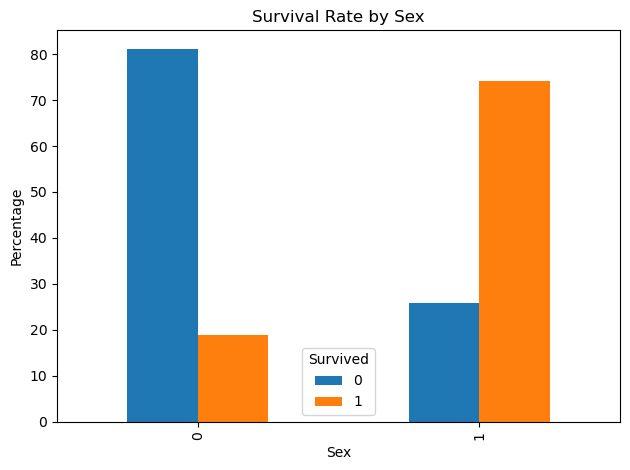

In [15]:
plt.figure(figsize=(4,2))
(pd.crosstab(df_train["Sex"], df_train["Survived"], normalize='index') * 100).plot(kind='bar')
plt.title("Survival Rate by Sex")
plt.ylabel("Percentage")
plt.tight_layout()

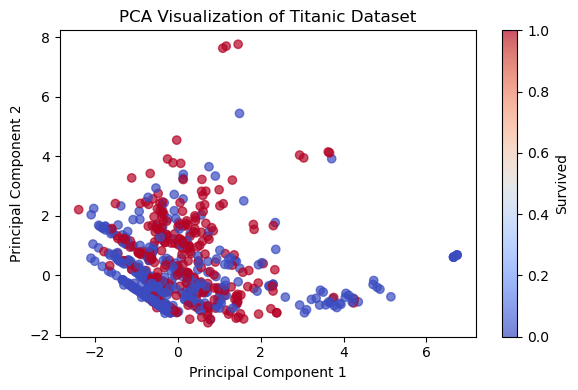

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
plt.figure(figsize=(6,4))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Titanic Dataset")
plt.colorbar(scatter, label="Survived")
plt.tight_layout()

In [17]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_tr, y_tr)
val_pred = model.predict(X_val)
print("Accuracy :", accuracy_score(y_val, val_pred))
print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred))

Accuracy : 0.8100558659217877
[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



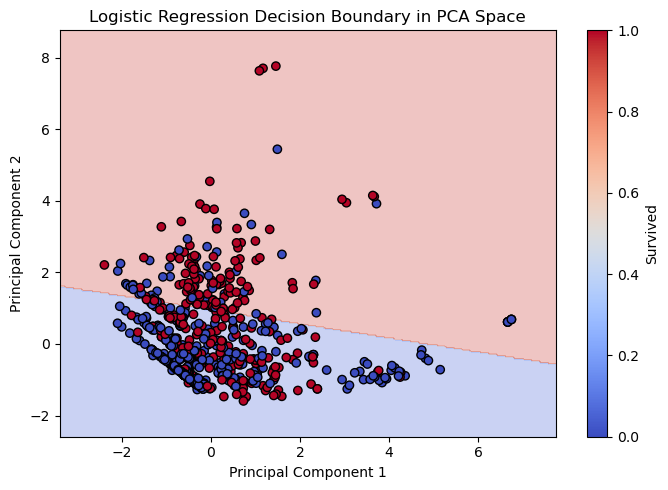

In [18]:
clf = LogisticRegression()
clf.fit(X_pca, y_train)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Logistic Regression Decision Boundary in PCA Space")
plt.colorbar(scatter, label="Survived")
plt.tight_layout()

In [19]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()
coef_df.sort_values("AbsCoeff", ascending=False)

,Feature,Coefficient,AbsCoeff
1,Sex,2.589500,2.589500
0,Pclass,-0.936192,0.936192
7,Embarked_S,-0.401719,0.401719
2,Age,-0.392673,0.392673
3,SibSp,-0.294487,0.294487
5,Fare,0.126129,0.126129
6,Embarked_Q,-0.113417,0.113417
4,Parch,-0.106873,0.106873


# Conclusion
- Performed preprocessing including missing value handling, categorical encoding, and feature scaling.
- Explored the dataset using EDA, PCA visualization, and logistic regression decision boundary analysis.
- Trained a Logistic Regression model achieving approximately 81% validation accuracy.
- Logistic Regression coefficients indicate that Sex, Pclass, and Age were among the most influential features in survival prediction.
- Concluded that Titanic survival prediction is moderately separable and can be modeled effectively using basic machine learning techniques.